In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis
import torch
import warnings
warnings.filterwarnings("ignore")

In [ ]:
DATASET_PATH = r"D:\task\Images"   # change if needed
DEVICE_ID = 0 if torch.cuda.is_available() else -1

In [ ]:
face_app = FaceAnalysis(name="buffalo_l")
face_app.prepare(ctx_id=DEVICE_ID)

print("buffalo_l loaded successfully")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [4]:
def collect_images(split="train"):
    images = []
    labels = []
    label_map = {}
    label_id = 0

    for person in os.listdir(DATASET_PATH):
        person_path = os.path.join(DATASET_PATH, person)
        if not os.path.isdir(person_path):
            continue

        if person not in label_map:
            label_map[person] = label_id
            label_id += 1

        for folder in os.listdir(person_path):
            folder_lower = folder.lower()

            if split == "train" and "high" in folder_lower:
                quality_path = os.path.join(person_path, folder)
            elif split == "eval" and "low" in folder_lower:
                quality_path = os.path.join(person_path, folder)
            else:
                continue

            for file in os.listdir(quality_path):
                if file.lower().endswith((".jpg", ".png", ".jpeg")):
                    images.append(os.path.join(quality_path, file))
                    labels.append(label_map[person])

    return images, labels, label_map

In [5]:
import cv2
import numpy as np
import random
import os

def augment_hq_images():
    print("Augmenting HQ images by 40%...")

    for person in os.listdir(DATASET_PATH):
        person_path = os.path.join(DATASET_PATH, person)
        if not os.path.isdir(person_path):
            continue

        for folder in os.listdir(person_path):
            if "high" not in folder.lower():
                continue

            hq_path = os.path.join(person_path, folder)
            images = [f for f in os.listdir(hq_path) 
                      if f.lower().endswith((".jpg", ".png", ".jpeg"))]

            num_to_augment = int(len(images) * 0.4)
            selected_images = random.sample(images, num_to_augment)

            for img_name in selected_images:
                img_path = os.path.join(hq_path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                aug_img = img.copy()

                # Random horizontal flip
                if random.random() > 0.5:
                    aug_img = cv2.flip(aug_img, 1)

                # Random brightness change
                brightness = random.randint(-30, 30)
                aug_img = np.clip(aug_img + brightness, 0, 255).astype(np.uint8)

                # Small random rotation
                angle = random.uniform(-10, 10)
                h, w = aug_img.shape[:2]
                M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
                aug_img = cv2.warpAffine(aug_img, M, (w, h))

                new_name = "aug_" + img_name
                cv2.imwrite(os.path.join(hq_path, new_name), aug_img)

    print("Augmentation completed.")

augment_hq_images()

train_paths, train_labels, label_map = collect_images("train")
eval_paths, eval_labels, _ = collect_images("eval")

print("Identities:", len(label_map))
print("Train images:", len(train_paths))
print("Eval images:", len(eval_paths))

Augmenting HQ images by 40%...
Augmentation completed.
Identities: 8
Train images: 7915
Eval images: 17818


In [ ]:
def get_embedding(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    faces = face_app.get(img)
    if len(faces) == 0:
        return None

    return faces[0].embedding  # 512-d


def extract_embeddings(paths, labels):
    embeddings = []
    valid_labels = []

    for path, label in tqdm(zip(paths, labels), total=len(paths)):
        emb = get_embedding(path)
        if emb is not None:
            embeddings.append(emb)
            valid_labels.append(label)

    return np.array(embeddings), np.array(valid_labels)

In [7]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [ ]:
baseline_emb, baseline_lbl = extract_embeddings(eval_paths, eval_labels)

np.save("baseline_embeddings.npy", baseline_emb)
np.save("baseline_labels.npy", baseline_lbl)

print("Baseline embeddings saved successfully.")

100%|██████████| 17818/17818 [1:45:17<00:00,  2.82it/s]  

Baseline embeddings saved successfully.


In [ ]:
def compute_similarity(embeddings, labels):
    sims = []
    truths = []

    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = np.dot(embeddings[i], embeddings[j])
            sims.append(sim)
            truths.append(int(labels[i] == labels[j]))

    return np.array(sims), np.array(truths)

Baseline AUC: 0.8360263638716398


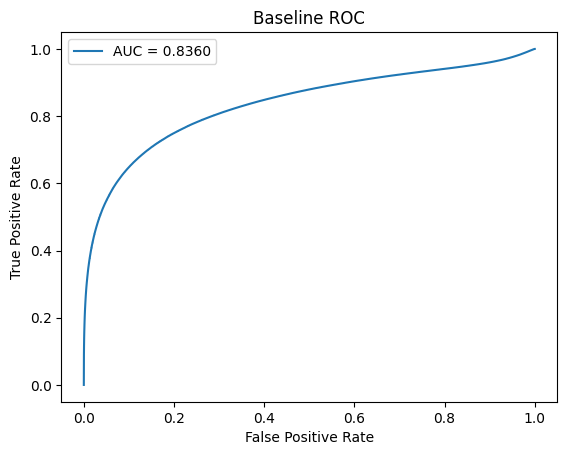

In [ ]:
sims, truths = compute_similarity(baseline_emb, baseline_lbl)

fpr, tpr, _ = roc_curve(truths, sims)
roc_auc = auc(fpr, tpr)

print("Baseline AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline ROC")
plt.legend()
plt.show()

In [ ]:
train_emb, train_lbl = extract_embeddings(train_paths, train_labels)

clf = LogisticRegression(max_iter=2000)
clf.fit(train_emb, train_lbl)

print("Classifier trained on HQ embeddings")

100%|██████████| 7915/7915 [07:40<00:00, 17.18it/s] 


Classifier trained on HQ embeddings


In [ ]:
import joblib

joblib.dump(clf, "face_classifier.pkl")

joblib.dump(label_map, "label_map.pkl")

print("Model and label_map saved successfully.")


Model and label_map saved successfully.


In [ ]:
eval_emb = np.load("baseline_embeddings.npy")
eval_lbl = np.load("baseline_labels.npy")

clf = joblib.load("face_classifier.pkl")

probabilities = clf.predict_proba(eval_emb)

print("Probabilities extracted from saved embeddings.")

Probabilities extracted from saved embeddings.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

train_emb, train_lbl = extract_embeddings(train_paths, train_labels)

train_emb = torch.tensor(train_emb, dtype=torch.float32)
train_lbl = torch.tensor(train_lbl)

print("Train embeddings shape:", train_emb.shape)

100%|██████████| 7915/7915 [07:34<00:00, 17.43it/s] 

Train embeddings shape: torch.Size([14, 512])


In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

class MetricLayer(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.fc = nn.Linear(dim, dim)

    def forward(self, x):
        x = self.fc(x)
        x = F.normalize(x)
        return x

metric_model = MetricLayer().to(DEVICE)

Using device: cpu


In [ ]:
def contrastive_loss(emb1, emb2, label, margin=0.5):
    cos_sim = F.cosine_similarity(emb1, emb2)
    loss_pos = (1 - cos_sim)[label == 1].mean() if (label == 1).any() else 0
    loss_neg = F.relu(cos_sim[label == 0] - margin).mean() if (label == 0).any() else 0
    return loss_pos + loss_neg

optimizer = optim.Adam(metric_model.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    metric_model.train()
    total_loss = 0
    
    for i in range(0, len(train_emb)-1, 32):
        batch_emb = train_emb[i:i+32].to(DEVICE)
        batch_lbl = train_lbl[i:i+32].to(DEVICE)

        emb1 = batch_emb[:-1]
        emb2 = batch_emb[1:]
        pair_label = (batch_lbl[:-1] == batch_lbl[1:]).float()

        out1 = metric_model(emb1)
        out2 = metric_model(emb2)

        loss = contrastive_loss(out1, out2, pair_label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 0.3984
Epoch 2, Loss: 0.1933
Epoch 3, Loss: 0.0916
Epoch 4, Loss: 0.1095
Epoch 5, Loss: 0.0386
Epoch 6, Loss: 0.0335
Epoch 7, Loss: 0.0364
Epoch 8, Loss: 0.0391
Epoch 9, Loss: 0.0407
Epoch 10, Loss: 0.0412
Epoch 11, Loss: 0.0405
Epoch 12, Loss: 0.0390
Epoch 13, Loss: 0.0370
Epoch 14, Loss: 0.0345
Epoch 15, Loss: 0.0318
Epoch 16, Loss: 0.0291
Epoch 17, Loss: 0.0263
Epoch 18, Loss: 0.0237
Epoch 19, Loss: 0.0213
Epoch 20, Loss: 0.0191


In [ ]:
eval_emb_tensor = torch.tensor(eval_emb, dtype=torch.float32).to(DEVICE)

metric_model.eval()
with torch.no_grad():
    refined_emb = metric_model(eval_emb_tensor).cpu().numpy()

print("Metric layer applied to saved embeddings.")

Metric layer applied to saved embeddings.


In [ ]:
def compute_similarity(embeddings, labels):
    sims = []
    truths = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sims.append(np.dot(embeddings[i], embeddings[j]))
            truths.append(int(labels[i] == labels[j]))
    return np.array(sims), np.array(truths)

sims_refined, truths_refined = compute_similarity(refined_emb, eval_lbl)

fpr2, tpr2, _ = roc_curve(truths_refined, sims_refined)
roc_auc2 = auc(fpr2, tpr2)

print("After Fine-Tune AUC:", roc_auc2)

After Fine-Tune AUC: 0.8184162109488278


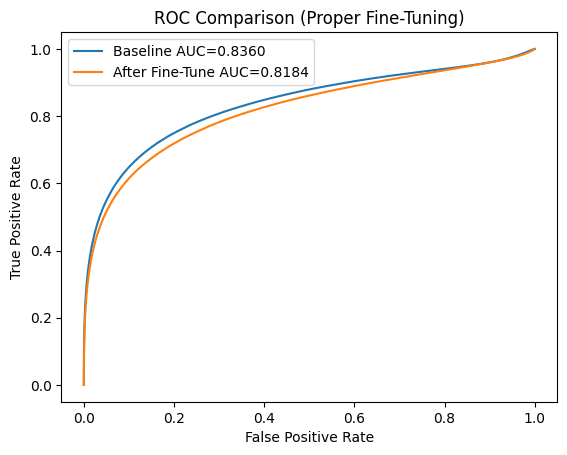

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"Baseline AUC={roc_auc:.4f}")
plt.plot(fpr2, tpr2, label=f"After Fine-Tune AUC={roc_auc2:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Proper Fine-Tuning)")
plt.legend()
plt.show()


In [ ]:
torch.save(metric_model.state_dict(), "metric_projection.pth")

print("Metric projection model saved successfully.")

Metric projection model saved successfully.


##CHECKING

In [24]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
from insightface.app import FaceAnalysis


In [25]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [26]:
face_app = FaceAnalysis(name="buffalo_l")
face_app.prepare(ctx_id=-1, det_size=(320, 320))  # tuned for your dataset
print("buffalo_l loaded.")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\kichu/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

In [27]:
class MetricLayer(torch.nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.fc = torch.nn.Linear(dim, dim)

    def forward(self, x):
        x = self.fc(x)
        x = F.normalize(x)
        return x
    
metric_model = MetricLayer().to(DEVICE)
metric_model.load_state_dict(torch.load("metric_projection.pth", map_location=DEVICE))
metric_model.eval()

print("Fine-tuned projection loaded.")

Fine-tuned projection loaded.


In [28]:
def get_embedding(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Image not found:", image_path)
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = face_app.get(img_rgb)

    if len(faces) == 0:
        print("Face not detected:", image_path)
        return None

    return faces[0].embedding

In [29]:
def compute_similarity_score(img1_path, img2_path):

    emb1 = get_embedding(img1_path)
    emb2 = get_embedding(img2_path)

    if emb1 is None or emb2 is None:
        return None, None

    emb1 = torch.tensor(emb1, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    emb2 = torch.tensor(emb2, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # -------- Baseline (No Fine-Tuning) --------
    with torch.no_grad():
        emb1_base = F.normalize(emb1)
        emb2_base = F.normalize(emb2)

    cos_base = F.cosine_similarity(emb1_base, emb2_base).item()
    similarity_base = (cos_base + 1) / 2

    # -------- After Fine-Tuning --------
    with torch.no_grad():
        emb1_ref = metric_model(emb1)
        emb2_ref = metric_model(emb2)

    cos_ref = F.cosine_similarity(emb1_ref, emb2_ref).item()
    similarity_ref = (cos_ref + 1) / 2

    return similarity_base, similarity_ref

In [44]:
hq_image = "D:\\task\\Images\\Ruvais\\High_quality\\aug_aug_frame36_face37.jpg"
lq_image = "D:\\task\\Images\\Firoz\\Low_quality\\a (187).png"

base_sim, fine_sim = compute_similarity_score(hq_image, lq_image)

if base_sim is not None:
    print(f"Baseline Similarity (0-1): {base_sim:.4f}")
    if base_sim > 0.60:
        print("Same Person")
    else:
        print("Different Person")

Baseline Similarity (0-1): 0.5062
Different Person


In [72]:
unique_ids = np.unique(labels)

train_ids = unique_ids[:6]
test_ids = unique_ids[6:]

train_mask = np.isin(labels, train_ids)
test_mask = np.isin(labels, test_ids)

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_test = embeddings[test_mask]
y_test = labels[test_mask]

In [73]:
np.save("train_embeddings.npy", X_train)
np.save("test_embeddings.npy", X_test)
np.save("train_labels.npy", y_train)
np.save("test_labels.npy", y_test)